# Supplementary Figure S2 — Benchmarking and validation against DSSR

In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

_ROOT = Path.cwd().parent.parent
FIGURES = _ROOT / "figures"

def data_file(rel):
    return _ROOT / "data" / rel

def savefig(fig, name, dpi=150):
    FIGURES.mkdir(exist_ok=True)
    fig.savefig(FIGURES / name, dpi=dpi, bbox_inches="tight")
    return Path("figures") / name

In [2]:
CWW_CANON_SEQS = {"GC", "CG", "AU", "UA"}


CLASS_ORDER = ["cWW (canon)", "cWW (non-canon)", "tWW", "cWH", "tWH", "cWS",
               "tWS", "cHH", "tHH", "cHS", "tHS", "cSS", "tSS"]


NONCWW_ORDER = ["tWW", "cWH", "tWH", "cWS", "tWS", "cHH", "tHH", "cHS", "tHS", "cSS", "tSS"]


def _canon_lw(lw):
    """Normalize an LW class to canonical face order (W < H < S)."""
    if not lw or len(lw) < 3:
        return lw
    o = {"W": 0, "H": 1, "S": 2}
    return lw[0] + lw[2] + lw[1] if o.get(lw[1], 0) > o.get(lw[2], 0) else lw


def _n_dssr_dotted(diffs):
    """python_only extras where DSSR's own edge label is undetermined ('.')."""
    n = 0
    for d in diffs:
        if d["source"] != "python_only":
            continue
        r = d.get("reason") or ""
        if (r.startswith("dssr_assigns:") and "." in r.split(":", 1)[1]) \
                or "." in (d.get("dssr_lw_class") or ""):
            n += 1
    return n


def _cww_split_metrics(cww_data, canonical):
    s = cww_data["summary"]
    diffs = cww_data["differences"]
    mbs = s["matched_by_sequence"]
    keep = (lambda q: q in CWW_CANON_SEQS) if canonical else (lambda q: q not in CWW_CANON_SEQS)
    matched = sum(v for k, v in mbs.items() if keep(k))
    dssr_only = [d for d in diffs if d["source"] == "dssr_only" and keep(d["sequence"])]
    py_only = [d for d in diffs if d["source"] == "python_only" and keep(d["sequence"])]
    total_dssr = matched + len(dssr_only)
    total_python = matched + len(py_only)
    cc = matched
    for d in dssr_only:
        r = d["reason"] or ""
        if r == "not_selected":
            cc += 1
        elif r.startswith("python_assigns:"):
            a = r.split(":", 1)[1]
            if "|" in a and "cWW" in [_canon_lw(p) for p in a.split("|")]:
                cc += 1
    mis = sum(1 for d in py_only if (d["reason"] or "").startswith("dssr_assigns:")
              and "." not in d["reason"].split(":", 1)[1]
              and _canon_lw(d["reason"].split(":", 1)[1]) != "cWW")
    return {
        "recall_sel": matched / total_dssr if total_dssr else 0,
        "recall_cls": cc / total_dssr if total_dssr else 0,
        "prec_sel": matched / total_python if total_python else 0,
        "prec_cls": cc / (cc + mis) if (cc + mis) else 0,
        "total_dssr": total_dssr, "total_python": total_python, "matched": matched,
    }


def build_metrics():
    """Return (metrics dict keyed by CLASS_ORDER, CLASS_ORDER list)."""
    cww_data = json.load(open(data_file("comparison/cWW.json")))
    noncww_dir = data_file("comparison")
    noncww = {f.stem: json.load(open(f)) for f in sorted(Path(noncww_dir).glob("*.json")) if f.stem != "cWW"}

    metrics = {
        "cWW (canon)": _cww_split_metrics(cww_data, True),
        "cWW (non-canon)": _cww_split_metrics(cww_data, False),
    }
    for lw in NONCWW_ORDER:
        s = noncww[lw].get("summary", noncww[lw])
        cc, mis = s["classified_correct"], s["classified_misclassified"]
        mis_f = mis - _n_dssr_dotted(noncww[lw]["differences"])
        metrics[lw] = {
            "recall_sel": s["recall"], "recall_cls": s["classified_recall"],
            "prec_sel": s["precision"],
            "prec_cls": cc / (cc + mis_f) if (cc + mis_f) else 0,
            "total_dssr": s["total_dssr_pairs"], "total_python": s["total_python_pairs"],
            "matched": s["matched"],
        }
    return metrics, CLASS_ORDER

## (A) Identification recall & precision by LW class

PARSE vs DSSR identification agreement, per LW class.

In [3]:
plt.rcParams.update({'font.size': 12, 'figure.dpi': 150})
metrics, CLASS_ORDER = build_metrics()

saved figures/figS2_A_identification_recall_precision.png


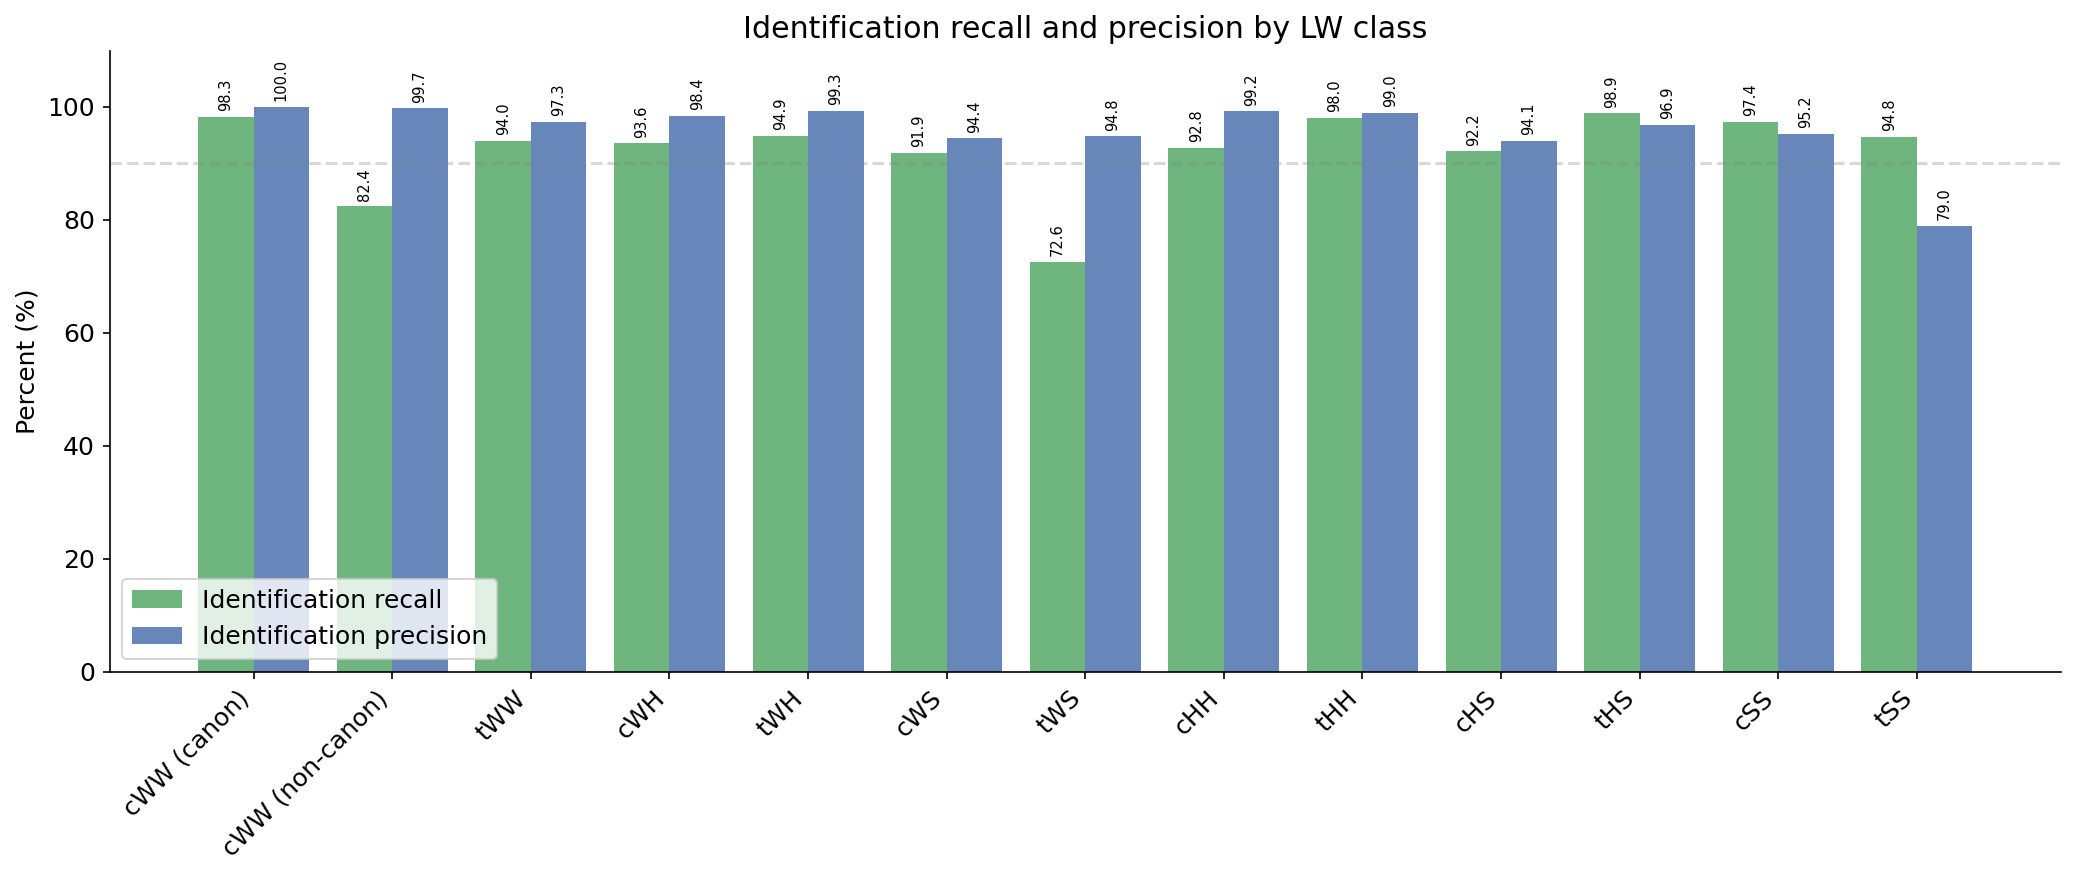

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(CLASS_ORDER)); width = 0.4
recall_cls = [metrics[c]['recall_cls'] * 100 for c in CLASS_ORDER]
prec_cls   = [metrics[c]['prec_cls']   * 100 for c in CLASS_ORDER]
bars_r = ax.bar(x - width/2, recall_cls, width, label='Identification recall',    color='#55A868', alpha=0.85)
bars_p = ax.bar(x + width/2, prec_cls,   width, label='Identification precision', color='#4C72B0', alpha=0.85)
ax.set_ylabel('Percent (%)')
ax.set_title('Identification recall and precision by LW class')
ax.set_xticks(x); ax.set_xticklabels(CLASS_ORDER, rotation=45, ha='right')
ax.set_ylim(0, 110)
ax.legend(loc='lower left')
ax.axhline(y=90, color='gray', linestyle='--', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
for bars in (bars_r, bars_p):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 1, f'{h:.1f}',
                ha='center', va='bottom', fontsize=7, rotation=90)
fig.tight_layout()
print('saved', savefig(fig, 'figS2_A_identification_recall_precision.png'))

## (B) Composition of PARSE–DSSR disagreements by LW class

The make-up of each LW class's disagreements with DSSR.

In [5]:
# comparison JSONs (one per LW class), flat in data/comparison/
NONCWW_ORDER = ["tWW", "cWH", "tWH", "cWS", "tWS", "cHH", "tHH", "cHS", "tHS", "cSS", "tSS"]
cww_data = json.load(open(data_file("comparison/cWW.json")))
noncww = {lw: json.load(open(data_file(f"comparison/{lw}.json"))) for lw in NONCWW_ORDER}

saved figures/figS2_B_disagreement_composition.png


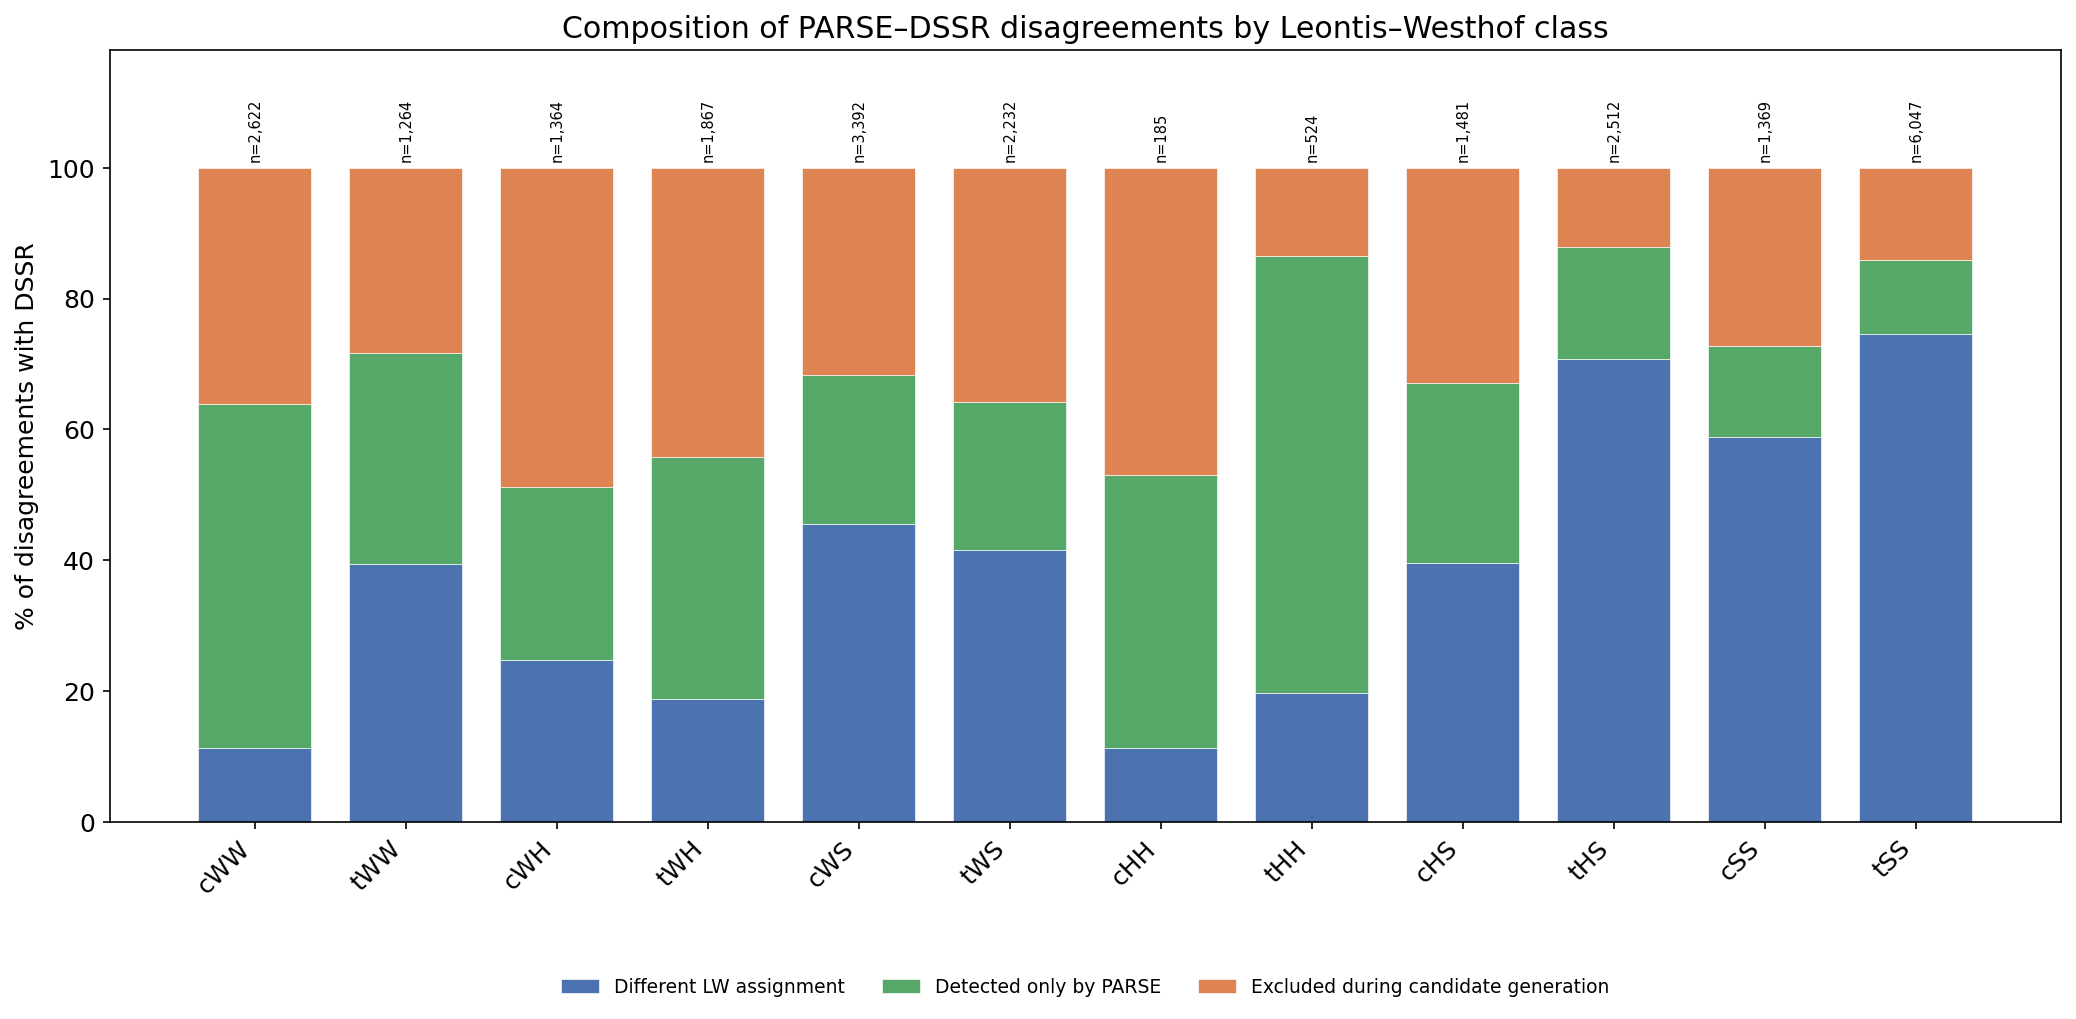

In [6]:
diffs_by_class = {"cWW": cww_data["differences"]}
diffs_by_class.update({c: noncww[c]["differences"] for c in NONCWW_ORDER})
REASON_CLS = ["cWW"] + NONCWW_ORDER

def _reason_bucket(e):
    r = e.get("reason") or ""
    if r.startswith("python_assigns:"):
        return None                 # misclassified = mirror of a class-disagree; drop
    if r.startswith("dssr_assigns:"):
        return "class-disagree"     # our pair; DSSR labels it a different class
    return r                        # not_candidate / failed_validation / novel / unknown

def _dssr_ambiguous(e):
    r = e.get("reason") or ""
    if r.startswith("dssr_assigns:") and "." in r.split(":", 1)[1]:
        return True
    return "." in (e.get("dssr_lw_class") or "")

ALL_ORDER = ["class-disagree", "novel", "not_candidate", "failed_validation", "unknown"]
ALL_COL = {"class-disagree": "#4C72B0", "novel": "#55A868",
           "not_candidate": "#DD8452", "failed_validation": "#C44E52", "unknown": "#B0B0B0"}
LABEL = {"class-disagree": "Different LW assignment",
         "novel": "Detected only by PARSE",
         "not_candidate": "Excluded during candidate generation",
         "failed_validation": "Failed validation", "unknown": "Other"}
EXCLUDE_REASONS = {"not_selected", "low_score", "no_strong_hbond", "stacking", "adjacent"}

allr, n_excl = {}, {}
for c in REASON_CLS:
    n_excl[c] = sum(1 for e in diffs_by_class[c] if _dssr_ambiguous(e))
    kept = [e for e in diffs_by_class[c]
            if not _dssr_ambiguous(e) and (e.get("reason") or "") not in EXCLUDE_REASONS]
    allr[c] = Counter(b for e in kept if (b := _reason_bucket(e)) is not None)

xx = np.arange(len(REASON_CLS))
totals = [sum(allr[c].values()) for c in REASON_CLS]
ALL_ORDER = [rb for rb in ALL_ORDER if sum(allr[c].get(rb, 0) for c in REASON_CLS) > 0]

fig, ax = plt.subplots(figsize=(14, 7))
bottom = np.zeros(len(REASON_CLS))
for rb in ALL_ORDER:
    vals = np.array([100 * allr[c].get(rb, 0) / max(totals[i], 1) for i, c in enumerate(REASON_CLS)])
    ax.bar(xx, vals, bottom=bottom, color=ALL_COL[rb], width=0.75,
           edgecolor="white", lw=0.3, label=LABEL[rb])
    bottom += vals
for i, t in enumerate(totals):
    ax.text(i, 101, f"n={t:,}", ha="center", va="bottom", fontsize=7, rotation=90)
ax.set_xticks(xx); ax.set_xticklabels(REASON_CLS, rotation=45, ha="right")
ax.set_ylim(0, 118); ax.set_ylabel("% of disagreements with DSSR")
ax.set_title("Composition of PARSE–DSSR disagreements by Leontis–Westhof class")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=len(ALL_ORDER),
          fontsize=9, frameon=False)
fig.tight_layout()
print("saved", savefig(fig, "figS2_B_disagreement_composition.png"))
plt.show()